# Workflow
This notebook illustrates the **madis-data** workflow. It performs the following tasks:

* download **Metar** surface observation data files for January 2026 from the [MADIS archive](https://madis-data.ncep.noaa.gov/madisPublic1/data/archive/),
* extract January 2026 data for stations in the state of Colorado of the following variables:
    - 2 m temperature,
    - 2 m dewpoint temperature,
    - 10 m west-east and south-north wind speed.
* save the extracted data in a s netCDF file,
* interpolate the data to full-hourly time series,
* save the full-hourly time series in a netCDF file,
* plot the original and the full-hourly interpolated time series at an individual station over select time intervals,
* plot the stations in the state of Colorado on a US map.

Downloading **Metar** data files from the [MADIS archive](https://madis-data.ncep.noaa.gov/madisPublic1/data/archive/) for one year is relatively quick (several hours), uses comparably little disk space (~ 12 GB / year), and little time (many minutes to an hour) to construct full-hourly time series for a selected region, owing to the small number of **Metar** stations.

This notebook can be modified to download **Mesonet** data files from the [MADIS archive](https://madis-data.ncep.noaa.gov/madisPublic1/data/archive/). This may take for one year substantial time (many hours to days) and disk space (several 100s of gigabytes), and significant time (several hours) to construct full-hourly time series for a selected region, owing to the large number of **Mesonet** stations.

In [1]:
# Automatically reload modules
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
from datetime import datetime, timedelta

import numpy as np
import xarray as xr
import pandas as pd
from matplotlib import pyplot as plt

import pandas as pd
import geopandas as gpd

import h5netcdf

In [3]:
from madis_data.metar import METAR_DATA_SOURCE, plot_locations_conus, extract_station_data, interpolate_to_full_hour, merge_hourly
from madis_data.spatial_filter import filter_by_region
from madis_data.stations import download_station_data
from madis_data.xarray_tools import get_missing_value, mask_with_missing_value


## Helper functions

In [4]:
def elapsed_time(time_start: datetime | None = None) -> datetime:
    if time_start:
        print('Elapsed time: ' + str(datetime.now()-time_start))
    return datetime.now()

## Settings

In [5]:
start_date = datetime(2025,12,31,0,0,0)
end_date = datetime(2026,1,31,23,0,0)

In [6]:
data_dir = Path('data') / 'Metar'

In [7]:
file_tag = str(start_date).replace(' ','_') + '-' + str(end_date).replace(' ','_')

## Download and pre-process MADIS METAR data

For some dates and times, no data files are available on the server, and the following will issue corresponding warnings.

In [8]:
time_start = elapsed_time()

In [9]:
metar_files = download_station_data(start_date, end_date, data_dir, source=METAR_DATA_SOURCE, n_jobs=24, refresh=False)

Progress: 46.88 %Download generated an exception: HTTPSConnectionPool(host='madis-data.ncep.noaa.gov', port=443): Read timed out. (read timeout=10)
Progress: 100.00 %


In [10]:
time_start = elapsed_time(time_start)

Elapsed time: 0:08:43.815818


## Isolate data for stations in Colorado

In [11]:
time_start = elapsed_time()

In [12]:
region_name = 'CO'

In [13]:
ds_region = filter_by_region(metar_files, region_name, n_jobs=24)

ERROR 1: PROJ: proj_create_from_database: Open of /home/jkazil/Software/miniforge3/envs/madis-data-dev/share/proj failed
Scanning station metadata: 100%|██████████| 767/767 files [00:07<00:00, 102.99files/s]
Extracting regional records: 100%|██████████| 767/767 files [00:07<00:00, 97.42files/s] 


In [14]:
time_start = elapsed_time(time_start)

Elapsed time: 0:00:16.103181


Save the data for the region as a netCDF file

In [15]:
region_out_file_name = region_name + '.' + file_tag  + '.nc'

In [16]:
region_out_file = data_dir / Path(region_out_file_name)

In [17]:
ds_region.to_netcdf(region_out_file)

## Plot stations in the region on a map

In [18]:
plot_file_name = region_name + '.' + file_tag  + '_stations.png'
plot_file = data_dir / plot_file_name

plot_file = plot_locations_conus(
    list(ds_region['stationID'].values),
    list(ds_region['latitude'].values),
    list(ds_region['longitude'].values),
    plot_file)

## Isolate time series for each station in the region

In [19]:
time_start = elapsed_time()

In [20]:
station_ids = list(ds_region['stationID'].values)

In [21]:
ds_station_dict = extract_station_data(ds_region,station_ids)

Extracting data by station ...
Completed loading data to memory - moving on to preparation of station identifiers ...
Completed preparation of station identifiers - moving on to selection of data at requested stations ...
Completed selection of data at requested stations - moving on to assembling valid data at requested stations ...
Completed assembling valid data at requested stations - moving on to building datasets for requested stations ...
Completed building datasets for requested stations


In [22]:
time_start = elapsed_time(time_start)

Elapsed time: 0:00:00.623942


## Interpolate to full-hourly time series for January 2026

In [23]:
time_start = elapsed_time()

In [24]:
start_date_hourly = datetime(2026,1,1,0,0,0)
end_date_hourly = datetime(2026,1,31,23,0,0)

In [25]:
ds_station_hourly_dict = interpolate_to_full_hour(ds_station_dict,start_date=start_date_hourly,end_date=end_date_hourly)

Interpolating time series to full hour ...
Progress: 100.00 %


In [26]:
ds_hourly = merge_hourly(ds_station_hourly_dict)

In [27]:
time_start = elapsed_time(time_start)

Elapsed time: 0:00:04.252458


Save the full-hourly interpolated data as a netCDF file

In [28]:
file_tag_hourly = str(start_date_hourly).replace(' ','_') + '-' + str(end_date_hourly).replace(' ','_') + '.hourly'

In [29]:
region_out_file_name_hourly = region_name + '.' + file_tag_hourly + '.nc'

In [30]:
ds_hourly.to_netcdf(data_dir / Path(region_out_file_name_hourly), engine='h5netcdf', mode='w')

## Plot the original time series and the full-hourly interpolated time series for a given station

Select a station

In [31]:
station_id = 'KDEN'

Find the array index of the station in the full-hourly interpolated dataset

In [32]:
station_ix = np.flatnonzero(ds_hourly['station'].values == station_id)

Time range to plot

In [33]:
time_min = max(ds_station_dict[station_id]['time'][0],ds_hourly['time'][0])
time_max = min(ds_station_dict[station_id]['time'][-1],ds_hourly['time'][-1])

Time zone

In [34]:
units = ds_hourly['time'].encoding['units']
reference_time = pd.Timestamp(units.split(' since ', 1)[1])
timezone = str(reference_time.tz)

Plot title

In [35]:
title = 'Station ' + station_id + ', ' + ds_hourly['STATION_NAME'][station_ix].values[0] + ', ' \
       + str(ds_hourly['LAT'][station_ix].values[0]) + ds_hourly['LAT'].attrs['units'] + ', ' \
       + str(ds_hourly['LON'][station_ix].values[0]) + ds_hourly['LON'].attrs['units'] + ', ' \
       + str(ds_hourly['ELEV'][station_ix].values[0]) + ' ' + ds_hourly['ELEV'].attrs['units']

Do your worst

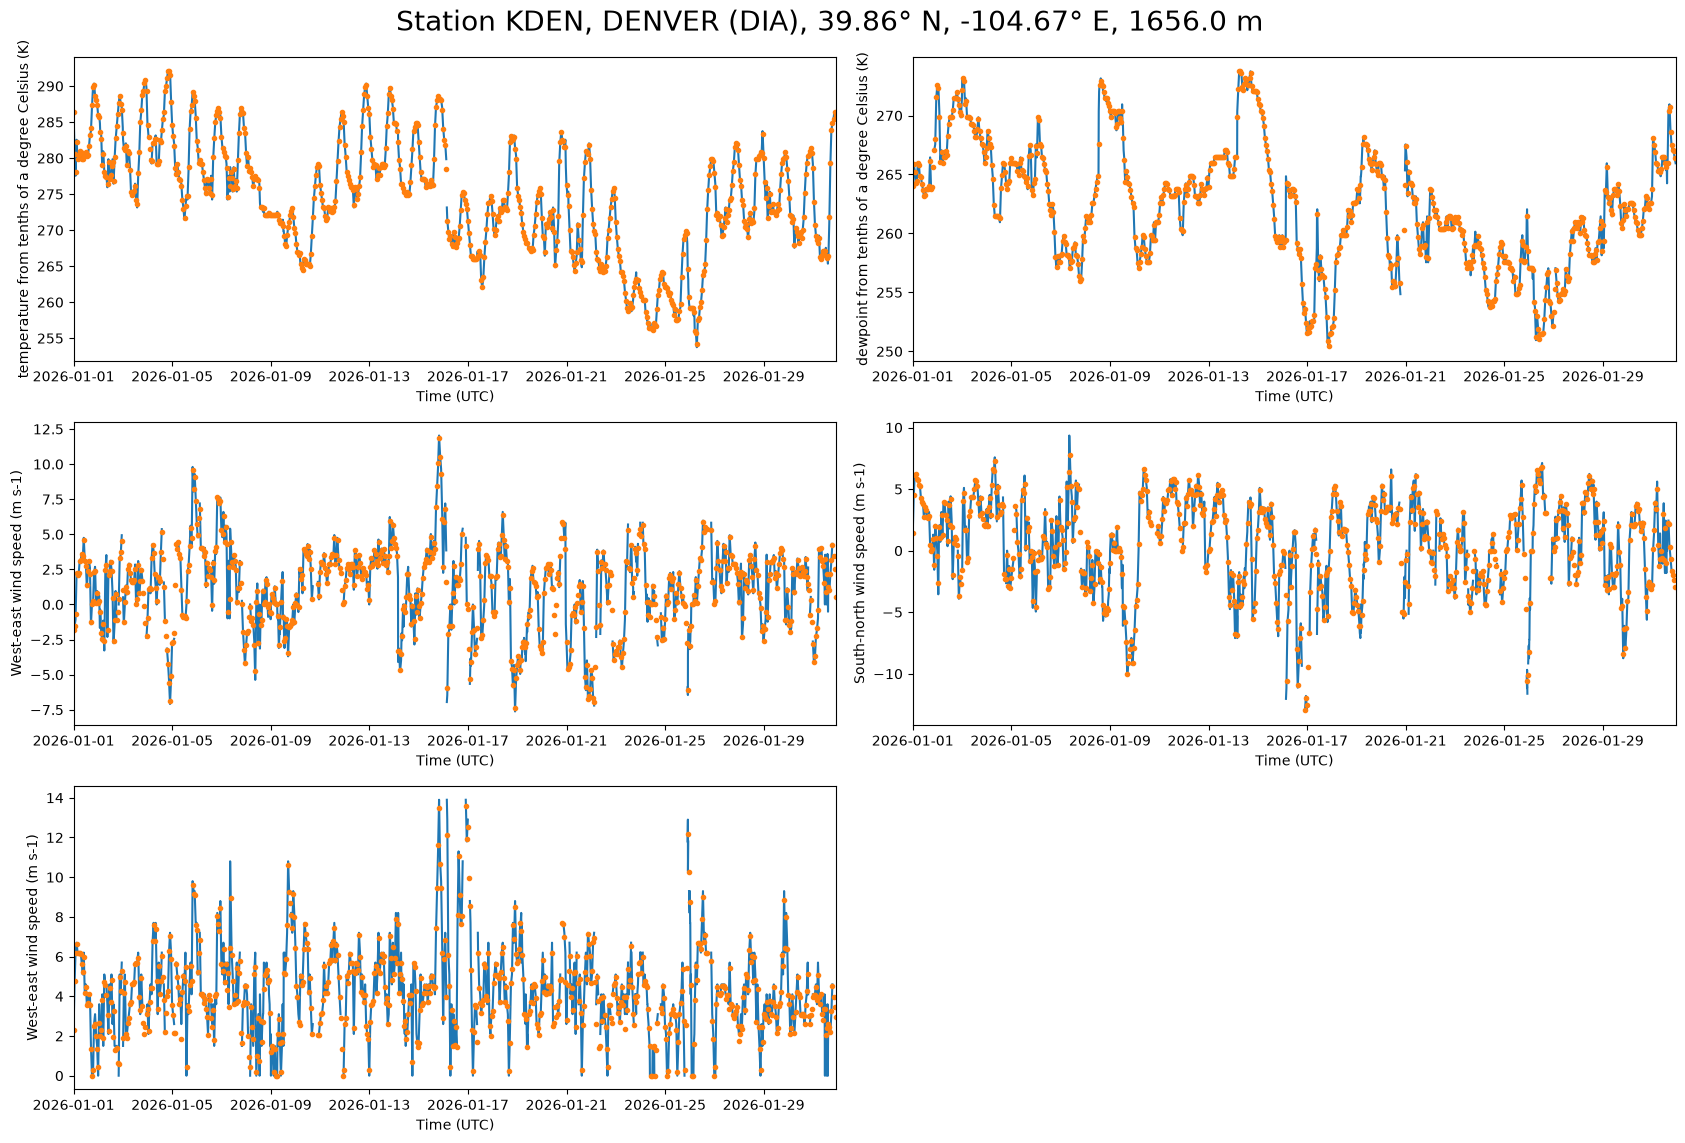

In [36]:
fig, axes = plt.subplots(3,2,figsize=(18,12),squeeze=False)

fig.suptitle(title, fontsize=20, y=0.98,)

fig.subplots_adjust(left=0.08,right=0.97,bottom=0.08,top=0.94,wspace=0.10,hspace=0.20)

var_name = 'temperature'
axes[0,0].plot(ds_station_dict[station_id]['time'],ds_station_dict[station_id][var_name][:].values)
axes[0,0].plot(ds_hourly['time'],ds_hourly[var_name][:,station_ix].values,marker='.',linewidth=0)
axes[0,0].set_ylabel(ds_hourly[var_name].attrs['long_name'] + ' (' + ds_hourly[var_name].attrs['units'] + ')')

var_name = 'dewpoint'
axes[0,1].plot(ds_station_dict[station_id]['time'],ds_station_dict[station_id][var_name][:].values)
axes[0,1].plot(ds_hourly['time'],ds_hourly[var_name][:,station_ix].values,marker='.',linewidth=0)
axes[0,1].set_ylabel(ds_hourly[var_name].attrs['long_name'] + ' (' + ds_hourly[var_name].attrs['units'] + ')')

var_name = 'U10'
axes[1,0].plot(ds_station_dict[station_id]['time'],ds_station_dict[station_id][var_name][:].values)
axes[1,0].plot(ds_hourly['time'],ds_hourly[var_name][:,station_ix].values,marker='.',linewidth=0)
axes[1,0].set_ylabel(ds_hourly[var_name].attrs['long_name'] + ' (' + ds_hourly[var_name].attrs['units'] + ')')

var_name = 'V10'
axes[1,1].plot(ds_station_dict[station_id]['time'],ds_station_dict[station_id][var_name][:].values)
axes[1,1].plot(ds_hourly['time'],ds_hourly[var_name][:,station_ix].values,marker='.',linewidth=0)
axes[1,1].set_ylabel(ds_hourly[var_name].attrs['long_name'] + ' (' + ds_hourly[var_name].attrs['units'] + ')')

var_name = 'Wind speed'
axes[2,0].plot(ds_station_dict[station_id]['time'],np.sqrt(ds_station_dict[station_id]['U10'][:]**2+ds_station_dict[station_id]['V10'][:]**2))
axes[2,0].plot(ds_hourly['time'],np.sqrt(ds_hourly['U10'][:,station_ix]**2+ds_hourly['V10'][:,station_ix]**2),marker='.',linewidth=0)
axes[2,0].set_ylabel(ds_hourly['U10'].attrs['long_name'] + ' (' + ds_hourly['U10'].attrs['units'] + ')')

axes[2,1].axis('off')

for ax in axes.flat:
    ax.set_xlim([time_min,time_max])
    ax.set_xlabel('Time (' + timezone + ')')